# Challenges of Expedia



### Description 

Planning your dream vacation, or even a weekend escape, can be an overwhelming affair. With hundreds, even thousands, of hotels to choose from at every destination, it's difficult to know which will suit your personal preferences. Should you go with an old standby with those pillow mints you like, or risk a new hotel with a trendy pool bar? 
 
Expedia wants to take the proverbial rabbit hole out of hotel search by providing personalized hotel recommendations to their users. This is no small task for a site with hundreds of millions of visitors every month!

Currently, Expedia uses search parameters to adjust their hotel recommendations, but there aren't enough customer specific data to personalize them for each user. In this competition, Expedia is challenging Kagglers to contextualize customer data and predict the likelihood a user will stay at 100 different hotel groups.
The data in this competition is a random selection from Expedia and is not representative of the overall statistics. 

https://www.kaggle.com/c/expedia-hotel-recommendations


In [4]:
%matplotlib inline
import random
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import numpy as np
import scipy
from scipy import stats
import seaborn as sns

random.seed(300)


# 1. Better Sampling

Kaggle competition contains a bigger dataset, which is a bit too big for the computation power that we have. We are going to downsample to smaller size.

There are two files that we are going to make. 
One is simply sample 160000 records from the bigger data source. The file name is called train_ds_n.csv. 
It's generated in seperated notebook named Appendix-Downsample.ipynb 
This file is suitable to use for exploratory analysis and doing A/B testing. 

However, we've found that the number of positive case is quite small. It's around 7%. If the amount of positive case is too little then it will be hard to build a good model. So we are going to generate another data file. This time we will randomly sample 80000 records with is_balance = 1 and 80000 records with is_balance = 0. The file name is train_ds.csv and this will be used for model training

In [5]:
# The file is random sample 80000 records.
train = pd.read_csv('train_ds_n.csv')

# Change the datatype of feature that's time related
train['date_time']= pd.to_datetime(train['date_time']) 
train['srch_ci']= pd.to_datetime(train['srch_ci']) 
train['srch_co']= pd.to_datetime(train['srch_co']) 

In [6]:
# Merge it with the review data
review = pd.read_csv('destinations.csv')
train = pd.merge(train, review, on='srch_destination_id',how='left')

# Data Preparation

First, let's check the null values

### Train Dataframe

In [7]:
null_check = train.isnull().sum()
null_check[null_check > 0]

orig_destination_distance    57660
srch_ci                        203
srch_co                        203
d1                             719
d2                             719
                             ...  
d145                           719
d146                           719
d147                           719
d148                           719
d149                           719
Length: 152, dtype: int64

There are a huge number of data without orig_destination_distance. According to kaggle data specification. It means the destination distance cannot be calculated. Taking a look of those data, a portion of them actually did booking eventually.

It doesn't make sense to fill that with zero or other values. Removing them will remove a big portion of the training data. If we are using model that is ok with missing values, we should keep them. 

In [8]:
train[train["orig_destination_distance"].isnull()]["is_booking"].value_counts()

0    53363
1     4297
Name: is_booking, dtype: int64

In [9]:
train[train["srch_ci"].isnull()]["is_booking"].value_counts()

0    203
Name: is_booking, dtype: int64

In [10]:
train[train["srch_co"].isnull()]["is_booking"].value_counts()

0    203
Name: is_booking, dtype: int64

If a search doesn't contain Check in and check out date, none of them make a booking eventually

Again, if the type of model we use are able to handle null values, we should just leave it to model. 

### Review Dataframe
Review dataframe has no null value

In [11]:
review.isnull().sum().sum()

0

Let's prepare the data first. The review dataframe has a lot of undisclosed features but those should be quite useful for the model building. We should merge it with the train dataset. As there could be new hotel without review, so we use left join and expect those value could be null.

Let's keep the null values for now. Some of the model that we are going to try like Random Forest or Gradient Boosting can handle the null values well.

Check how many items has no d1 to d149 values

In [12]:
len(train[train["d1"].isnull()])

719

There are only 719 out of 80000 records having no d1 to d149 values, which is minority

# 3. Exploratory Data Analysis

The real values are masked. We don't know what are those continent are

<AxesSubplot:xlabel='hotel_continent', ylabel='count'>

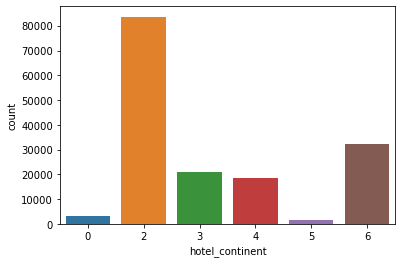

In [13]:
sns.countplot(x='hotel_continent', data=train)

<AxesSubplot:xlabel='srch_rm_cnt', ylabel='count'>

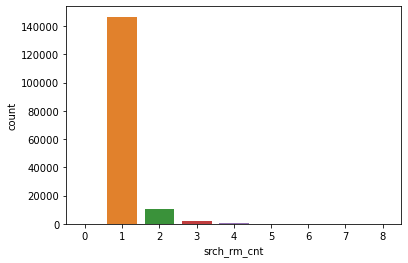

In [14]:
sns.countplot(x='srch_rm_cnt', data=train)

Booking Count

<AxesSubplot:xlabel='is_booking', ylabel='count'>

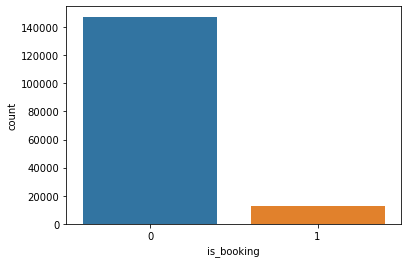

In [15]:
sns.countplot(x='is_booking', data=train)

Overal booking percentage

In [16]:
train["is_booking"].mean()

0.0792625

Which channel is better for booking?

<AxesSubplot:xlabel='channel', ylabel='count'>

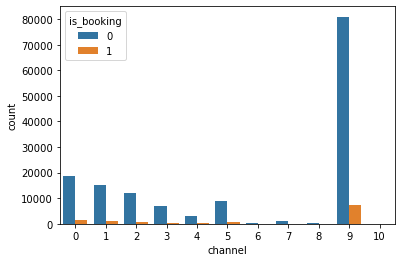

In [17]:
sns.countplot(hue='is_booking', x='channel', data=train)

<AxesSubplot:xlabel='cnt', ylabel='count'>

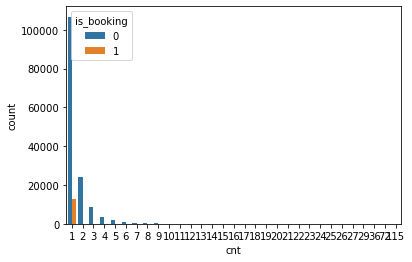

In [18]:
sns.countplot(hue='is_booking', x='cnt', data=train)

It seems that most success booking only has 1 similar events in the context of the same user session

In [19]:
# A function to show the percentage of booking for different value of specified column

def feature_booking_pc(col_name):
    train.groupby(col_name).apply(lambda g: g["is_booking"].mean()).plot(kind='bar')


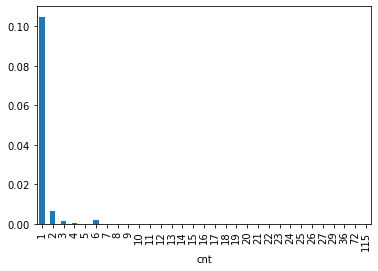

In [20]:
feature_booking_pc("cnt")

We've found that if cnt=1, the booking percentage is over 10%, while if cnt is other values, the booking percentage is much lower

<AxesSubplot:xlabel='srch_adults_cnt', ylabel='count'>

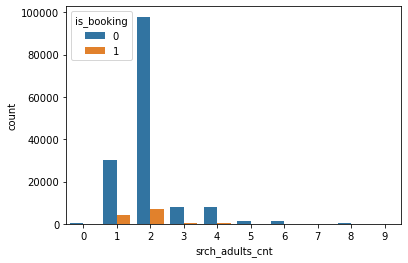

In [21]:
sns.countplot(hue='is_booking', x='srch_adults_cnt', data=train)

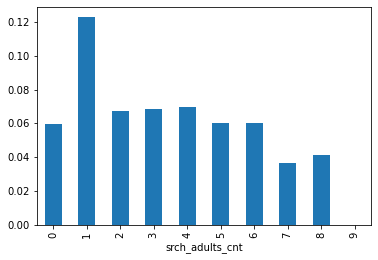

In [22]:
feature_booking_pc("srch_adults_cnt")

<AxesSubplot:xlabel='srch_children_cnt', ylabel='count'>

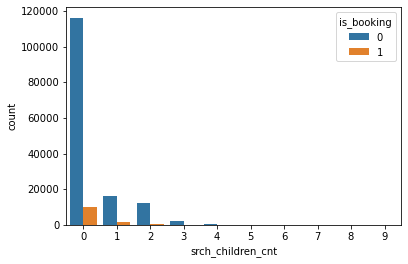

In [23]:
sns.countplot(hue='is_booking', x='srch_children_cnt', data=train)

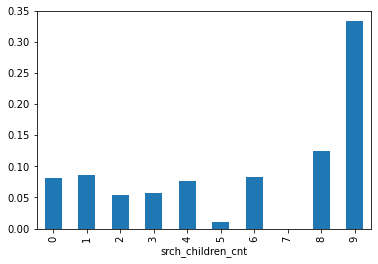

In [24]:
feature_booking_pc("srch_children_cnt")

<AxesSubplot:xlabel='srch_rm_cnt', ylabel='count'>

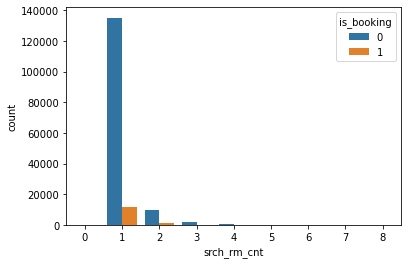

In [25]:
sns.countplot(hue='is_booking', x='srch_rm_cnt', data=train)

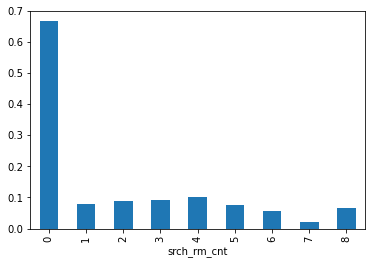

In [26]:
feature_booking_pc("srch_rm_cnt")

Though you see that if the specified room is zero, it has a higher chance than other values to book the room. Putting it zero means not specifying the number of room during searching. And there are higher percentage of them than other value to purchase.

In [27]:
train["srch_ci"]

0        2013-07-26
1        2014-11-27
2        2014-05-25
3        2014-02-27
4        2014-08-14
            ...    
159995   2014-08-25
159996   2014-05-15
159997   2014-12-18
159998   2014-08-17
159999   2014-05-24
Name: srch_ci, Length: 160000, dtype: datetime64[ns]

In [28]:
train["srch_co"]

0        2013-07-27
1        2014-11-29
2        2014-05-26
3        2014-03-01
4        2014-08-17
            ...    
159995   2014-09-01
159996   2014-05-18
159997   2014-12-21
159998   2014-08-18
159999   2014-05-30
Name: srch_co, Length: 160000, dtype: datetime64[ns]

Simply check in and check out date is not useful information. We probably need to have feature like month, day, day of week (which are easy to generate), or public holiday (which is hard to get as different location has different holiday). Moreover, it's not about just the check in and check out date. It's about the dates between the check in and check out date. It could happen that the check in is a Wednesday and check out is a Tuesday and it covers the weekends in the middle. There will be more effort to make sense of it. 

Let's create those feature

In [29]:
# days from now to check in date
train["days_to_ci"] = (train["srch_ci"] - train["date_time"]).dt.days

# trip duration in days
train["trip_duration"] = (train["srch_co"] - train["srch_ci"]).dt.days

train['date_time_year'] = train['date_time'].dt.year
train['date_time_month'] = train['date_time'].dt.month
train['date_time_day'] = train['date_time'].dt.day
train['date_time_dow'] = train['date_time'].dt.dayofweek
train["date_time_is_weekend"] = train["date_time_dow"].isin([5, 6]).astype(np.int8)
train['date_time_hour'] = train['date_time'].dt.hour

train['srch_ci_year'] = train['srch_ci'].dt.year
train['srch_ci_month'] = train['srch_ci'].dt.month
train['srch_ci_day'] = train['srch_ci'].dt.day
train['srch_ci_dow'] = train['srch_ci'].dt.dayofweek
train["srch_ci_is_weekend"] = train["srch_ci_dow"].isin([5, 6]).astype(np.int8)

train['srch_co_year'] = train['srch_co'].dt.year
train['srch_co_month'] = train['srch_co'].dt.month
train['srch_co_day'] = train['srch_co'].dt.day
train['srch_co_dow'] = train['srch_co'].dt.dayofweek
train["srch_co_is_weekend"] = train["srch_co_dow"].isin([5, 6]).astype(np.int8)

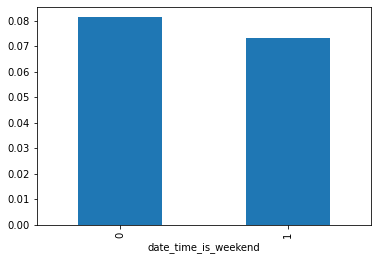

In [30]:
feature_booking_pc("date_time_is_weekend")

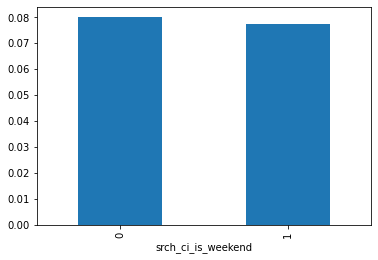

In [31]:
feature_booking_pc("srch_ci_is_weekend")

seems whether it's weekend or weekday doens't make much difference

<AxesSubplot:>

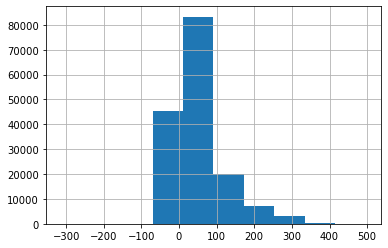

In [32]:
train["days_to_ci"].hist()

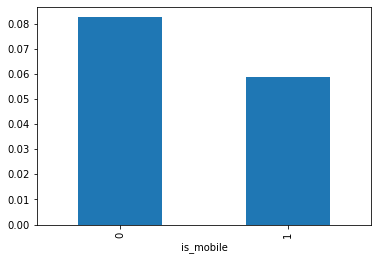

In [33]:
feature_booking_pc("is_mobile")

Non-mobile has higher booking percentage

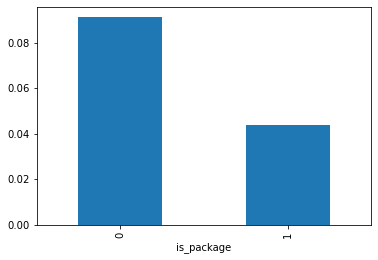

In [34]:
feature_booking_pc("is_package")

No package also has higher booking percnetage

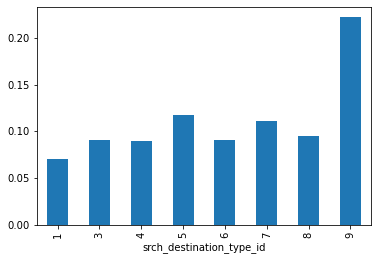

In [35]:
feature_booking_pc("srch_destination_type_id")

Some destination type has higher booking percentage

<AxesSubplot:>

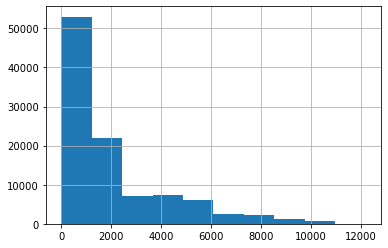

In [36]:
train["orig_destination_distance"].hist()

# 4. Modelling 

We have got some idea of the data after the exploratory data analysis. We've also add some date related features. We believe some factor are going to contribute to higher booking percentage. But we will put all features to the trianing model first.

We are going to try the following algorithm
1. Decision Tree
2. Decision Tree with Bagging
3. Random Forest
4. Boosting with sklearn
5. Boosting with XGBoost
6. Boosting with lightbgm

In [39]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

### 4.1 Using data with same amount of positive and negative case

In [40]:
train = pd.read_csv('train_ds.csv')
# use date time data type
train['date_time']= pd.to_datetime(train['date_time']) 
train['srch_ci']= pd.to_datetime(train['srch_ci']) 
train['srch_co']= pd.to_datetime(train['srch_co']) 

In [41]:
# create date related feature
train["days_to_ci"] = (train["srch_ci"] - train["date_time"]).dt.days
train["trip_duration"] = (train["srch_co"] - train["srch_ci"]).dt.days

train['date_time_year'] = train['date_time'].dt.year
train['date_time_month'] = train['date_time'].dt.month
train['date_time_day'] = train['date_time'].dt.day
train['date_time_dow'] = train['date_time'].dt.dayofweek
train["date_time_is_weekend"] = train["date_time_dow"].isin([5, 6]).astype(np.int8)
train['date_time_hour'] = train['date_time'].dt.hour

train['srch_ci_year'] = train['srch_ci'].dt.year
train['srch_ci_month'] = train['srch_ci'].dt.month
train['srch_ci_day'] = train['srch_ci'].dt.day
train['srch_ci_dow'] = train['srch_ci'].dt.dayofweek
train["srch_ci_is_weekend"] = train["srch_ci_dow"].isin([5, 6]).astype(np.int8)

train['srch_co_year'] = train['srch_co'].dt.year
train['srch_co_month'] = train['srch_co'].dt.month
train['srch_co_day'] = train['srch_co'].dt.day
train['srch_co_dow'] = train['srch_co'].dt.dayofweek
train["srch_co_is_weekend"] = train["srch_co_dow"].isin([5, 6]).astype(np.int8)


In [42]:
# for categorial value, do one hot encoding
train = pd.get_dummies(train, columns=["channel"], prefix=["channel_is"] )
train = pd.get_dummies(train, columns=["posa_continent"], prefix=["posa_continent_is"] )
train = pd.get_dummies(train, columns=["user_location_region"], prefix=["user_location_region_is"] )
train = pd.get_dummies(train, columns=["srch_destination_type_id"], prefix=["srch_destination_type_id"] )
train = pd.get_dummies(train, columns=["hotel_continent"], prefix=["hotel_continent"] )


Some categorial feature has huge amount of different categories. It doesn't make sense to create thoursands of feature. What we are going to do is to encode the top x item as individual cateogry and the rest as "others"

In [43]:
# categorial value with a lot of categories
to_keep = list(train["hotel_country"].value_counts().head(15).index)
train.loc[~train["hotel_country"].isin(to_keep),"hotel_country"] = 999999
train = pd.get_dummies(train, columns=["hotel_country"], prefix=["hotel_country"] )

to_keep = list(train["hotel_market"].value_counts().head(25).index)
train.loc[~train["hotel_market"].isin(to_keep),"hotel_market"] = 999999
train = pd.get_dummies(train, columns=["hotel_market"], prefix=["hotel_market"] )

to_keep = list(train["site_name"].value_counts().head(15).index)
train.loc[~train["site_name"].isin(to_keep),"site_name"] = 999999
train = pd.get_dummies(train, columns=["site_name"], prefix=["site_name"] )

to_keep = list(train["user_location_country"].value_counts().head(15).index)
train.loc[~train["user_location_country"].isin(to_keep),"user_location_country"] = 999999
train = pd.get_dummies(train, columns=["user_location_country"], prefix=["user_location_country"] )

to_keep = list(train["user_location_city"].value_counts().head(25).index)
train.loc[~train["user_location_city"].isin(to_keep),"user_location_city"] = 999999
train = pd.get_dummies(train, columns=["user_location_city"], prefix=["user_location_city"] )

In [44]:
# delete feature that we are not going to use
del train["user_id"]
del train["date_time_dow"]
del train["srch_ci_dow"]
del train["srch_co_dow"]
del train["date_time"]
del train["srch_ci"]
del train["srch_co"]
del train["hotel_cluster"]

In [45]:
# merge review
review = pd.read_csv('destinations.csv')
train = pd.merge(train, review, on='srch_destination_id',how='left')

del train["srch_destination_id"]

## 4.2 Spliting training and validation set for model building

In [46]:
train = train.dropna()
X = train.drop(['is_booking'], axis=1)
y = train["is_booking"]

Split training set and validation set (20%)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## 4.3 Decision Tree 

In [48]:
# Decision Tree build 
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [49]:
# Model result
y_pred = model.predict(X_test)

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('Area under curve',roc_auc_score(y_test, y_pred))
print('Train accuracy: %f'%model.score(X_train, y_train))
print('Test accuracy (Accuracy Score): %f'%metrics.accuracy_score(y_test, y_pred))


Mean Absolute Error: 0.3136874757658007
Mean Squared Error: 0.3136874757658007
Root Mean Squared Error: 0.5600780979165323
Area under curve 0.6816493760698783
Train accuracy: 0.681272
Test accuracy (Accuracy Score): 0.686313


In [50]:
# Confusion Metrics
df_confusion = confusion_matrix(y_test, y_pred)
df_conf_norm = df_confusion / df_confusion.sum(axis=1)
df_conf_norm

array([[0.52129925, 0.45164532],
       [0.16746539, 0.8419995 ]])

In [51]:
# Feature Importance
list_of_tuples = list(zip(X.columns, model.feature_importances_))
feat_im = pd.DataFrame(list_of_tuples, columns = ['Column', 'Feature Importance']) 
feat_im.sort_values(by="Feature Importance",ascending=False).head(10)

,Column,Feature Importance
6,cnt,0.668383
8,trip_duration,0.173424
3,srch_adults_cnt,0.042210
899,d30,0.037867
928,d59,0.031614
7,days_to_ci,0.024690
984,d115,0.006287
18,srch_co_year,0.005067
962,d93,0.002865
989,d120,0.001817


## 4.2 Decision Tree with Bagging

In [52]:
# Decision Tree with Bagging build 
model = BaggingClassifier(DecisionTreeClassifier(splitter="random", max_leaf_nodes=16, random_state=42),
           n_estimators=100, max_samples=1.0, bootstrap=True, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

BaggingClassifier(base_estimator=DecisionTreeClassifier(max_leaf_nodes=16,
                                                        random_state=42,
                                                        splitter='random'),
                  n_estimators=100, n_jobs=-1, random_state=42)

In [53]:
# Model result

y_pred = model.predict(X_test)

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('Area under curve',roc_auc_score(y_test, y_pred))
print('Train accuracy: %f'%model.score(X_train, y_train))
print('Test accuracy (Accuracy Score): %f'%metrics.accuracy_score(y_test, y_pred))


Mean Absolute Error: 0.30838826418508464
Mean Squared Error: 0.30838826418508464
Root Mean Squared Error: 0.5553271685998126
Area under curve 0.6878596857437043
Train accuracy: 0.688413
Test accuracy (Accuracy Score): 0.691612


In [54]:
# Confusion Metrics
df_confusion = confusion_matrix(y_test, y_pred)
df_conf_norm = df_confusion / df_confusion.sum(axis=1)
df_conf_norm

array([[0.55883919, 0.41622708],
       [0.19408946, 0.81688018]])

In [55]:
# Feature Importance

# bagging classifier do not has default feature importance implemented. we take the mean of the trees in the model
feature_importances = np.mean([
    tree.feature_importances_ for tree in model.estimators_
], axis=0)


list_of_tuples = list(zip(X.columns, feature_importances))
feat_im = pd.DataFrame(list_of_tuples, columns = ['Column', 'Feature Importance']) 
feat_im.sort_values(by="Feature Importance",ascending=False).head(10)

,Column,Feature Importance
6,cnt,0.534594
2,is_package,0.112140
8,trip_duration,0.066879
7,days_to_ci,0.035618
3,srch_adults_cnt,0.035073
765,hotel_continent_2,0.031446
928,d59,0.018627
878,d9,0.016240
18,srch_co_year,0.011252
876,d7,0.009159


## 4.3 Random Forest

In [56]:
# Random Forest build 
model = RandomForestClassifier(n_estimators = 100, random_state = 42)  
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [57]:
# Model result

y_pred = model.predict(X_test)

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('Area under curve',roc_auc_score(y_test, y_pred))
print('Train accuracy: %f'%model.score(X_train, y_train))
print('Test accuracy (Accuracy Score): %f'%metrics.accuracy_score(y_test, y_pred))


Mean Absolute Error: 0.336693808969885
Mean Squared Error: 0.336693808969885
Root Mean Squared Error: 0.5802532283149185
Area under curve 0.6625509709458586
Train accuracy: 0.999806
Test accuracy (Accuracy Score): 0.663306


In [58]:
# Confusion Metrics
df_confusion = confusion_matrix(y_test, y_pred)
df_conf_norm = df_confusion / df_confusion.sum(axis=1)
df_conf_norm

array([[0.63658147, 0.34287867],
       [0.33013845, 0.68852047]])

In [54]:
# Feature Importance
list_of_tuples = list(zip(X.columns, model.feature_importances_))
feat_im = pd.DataFrame(list_of_tuples, columns = ['Column', 'Feature Importance']) 
feat_im.sort_values(by="Feature Importance",ascending=False).head(10)

,Column,Feature Importance
6,cnt,0.063859
7,days_to_ci,0.045201
0,orig_destination_distance,0.042033
11,date_time_day,0.036514
16,srch_ci_day,0.035856
20,srch_co_day,0.035718
13,date_time_hour,0.035669
8,trip_duration,0.030564
10,date_time_month,0.029775
15,srch_ci_month,0.028701


## 4.4 Gradient Boosting with sklearn

In [59]:
# Gradient Boosting build 
model = GradientBoostingClassifier(random_state=10, learning_rate=0.1,
    n_estimators=200, max_depth=5, max_features=10)
model.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=5, max_features=10, n_estimators=200,
                           random_state=10)

In [60]:
# Model result

y_pred = model.predict(X_test)

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('Area under curve',roc_auc_score(y_test, y_pred))
print('Train accuracy: %f'%model.score(X_train, y_train))
print('Test accuracy (Accuracy Score): %f'%metrics.accuracy_score(y_test, y_pred))


Mean Absolute Error: 0.30102106759725994
Mean Squared Error: 0.30102106759725994
Root Mean Squared Error: 0.5486538686615269
Area under curve 0.6975090545907758
Train accuracy: 0.734813
Test accuracy (Accuracy Score): 0.698979


In [61]:
# Confusion Metrics
df_confusion = confusion_matrix(y_test, y_pred)
df_conf_norm = df_confusion / df_confusion.sum(axis=1)
df_conf_norm

array([[0.64696486, 0.33308214],
       [0.2670394 , 0.74805325]])

In [62]:
# Feature Importance
list_of_tuples = list(zip(X.columns, model.feature_importances_))
feat_im = pd.DataFrame(list_of_tuples, columns = ['Column', 'Feature Importance']) 
feat_im.sort_values(by="Feature Importance",ascending=False).head(10)

,Column,Feature Importance
6,cnt,0.351367
8,trip_duration,0.052509
933,d64,0.026461
7,days_to_ci,0.025004
3,srch_adults_cnt,0.023415
969,d100,0.012527
2,is_package,0.011959
18,srch_co_year,0.011502
939,d70,0.011159
898,d29,0.009635


## 4.5 Gradient Boosting with XGBoost

In [63]:
# XGBoost build 
model = XGBClassifier(random_state=10)
model.fit(X_train, y_train)

/Users/henrytang/.conda/envs/hkbu/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[11:46:18] WARNING: ../src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=10,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [64]:
# Model result

y_pred = model.predict(X_test)

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('Area under curve',roc_auc_score(y_test, y_pred))
print('Train accuracy: %f'%model.score(X_train, y_train))
print('Test accuracy (Accuracy Score): %f'%metrics.accuracy_score(y_test, y_pred))


Mean Absolute Error: 0.30425229417086724
Mean Squared Error: 0.30425229417086724
Root Mean Squared Error: 0.5515906944201173
Area under curve 0.6936092405379226
Train accuracy: 0.824835
Test accuracy (Accuracy Score): 0.695748


In [65]:
# Confusion Metrics
df_confusion = confusion_matrix(y_test, y_pred)
df_conf_norm = df_confusion / df_confusion.sum(axis=1)
df_conf_norm

array([[0.62007455, 0.35845265],
       [0.24680511, 0.76714393]])

In [66]:
# Feature Importance
list_of_tuples = list(zip(X.columns, model.feature_importances_))
feat_im = pd.DataFrame(list_of_tuples, columns = ['Column', 'Feature Importance']) 
feat_im.sort_values(by="Feature Importance",ascending=False).head(10)

,Column,Feature Importance
6,cnt,0.152265
8,trip_duration,0.017594
928,d59,0.015061
18,srch_co_year,0.012998
756,srch_destination_type_id_1,0.010374
899,d30,0.009399
3,srch_adults_cnt,0.008542
984,d115,0.008077
964,d95,0.007395
878,d9,0.007292


## 4.6 Gradient Boosting with LGBM

In [67]:
# LGBM build 
model = LGBMClassifier(random_state=10)
model.fit(X_train, y_train)

LGBMClassifier(random_state=10)

In [68]:
# Model result
y_pred = model.predict(X_test)

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('Area under curve',roc_auc_score(y_test, y_pred))
print('Train accuracy: %f'%model.score(X_train, y_train))
print('Test accuracy (Accuracy Score): %f'%metrics.accuracy_score(y_test, y_pred))


Mean Absolute Error: 0.2893886519322735
Mean Squared Error: 0.2893886519322735
Root Mean Squared Error: 0.5379485588160577
Area under curve 0.707924943802551
Train accuracy: 0.766867
Test accuracy (Accuracy Score): 0.710611


In [69]:
# Confusion Metrics
df_confusion = confusion_matrix(y_test, y_pred)
df_conf_norm = df_confusion / df_confusion.sum(axis=1)
df_conf_norm

array([[0.61554846, 0.36272293],
       [0.21166134, 0.80030143]])

In [70]:
# Feature Importance
list_of_tuples = list(zip(X.columns, model.feature_importances_))
feat_im = pd.DataFrame(list_of_tuples, columns = ['Column', 'Feature Importance']) 
feat_im.sort_values(by="Feature Importance",ascending=False).head(10)

,Column,Feature Importance
7,days_to_ci,122
8,trip_duration,118
0,orig_destination_distance,98
6,cnt,79
3,srch_adults_cnt,59
11,date_time_day,48
13,date_time_hour,47
10,date_time_month,46
1001,d132,40
2,is_package,37


## 4.7 Optimal Model

The Boosting with lgbm model has 
* the highest test accuracy 0.701877 
* It's true positive rate isn't the highest, nor the true negative rate. But it has a good balance and so it has the highest Area under curve 0.7 

We considered Boosting with lgbm model as the best model

Remarks: Which one is optimal model really depends on the business objective. One may prefer having highest true positive rate as that would maximum sales. If that's the case, the best model would be different.